In [2]:
# ============================================================
# Leukemia Detection using Xception + Quantum Fusion (TensorFlow)
# ============================================================

import os, random, gc, time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm

print(" TensorFlow version:", tf.__version__)
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

 TensorFlow version: 2.18.0


In [3]:
import os
root_dir = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data"
print(" Exists:", os.path.exists(root_dir))
print(" Subfolders:", os.listdir(root_dir))


 Exists: True
 Subfolders: ['fold_0', 'fold_1', 'fold_2']


In [4]:
import os
import tensorflow as tf
import numpy as np

def load_leukemia_dataset_safe(root_dir, img_size=(224, 224)):
    image_paths, labels = [], []
    print(f" Checking dataset path: {root_dir}")
    
    has_folds = any("fold_0" in d for d in os.listdir(root_dir))
    print(f" Has folds? {has_folds}")
    
    folds = ['fold_0', 'fold_1', 'fold_2'] if has_folds else [""]
    
    for fold in folds:
        for label, category in enumerate(['all', 'hem']):
            folder_path = os.path.join(root_dir, fold, category) if fold else os.path.join(root_dir, category)
            if os.path.exists(folder_path):
                count = 0
                for img_name in os.listdir(folder_path):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                        image_paths.append(os.path.join(folder_path, img_name))
                        labels.append(label)
                        count += 1
                print(f"    Found {count} images in {folder_path}")
            else:
                print(f" Missing folder: {folder_path}")

    print(f"\n Total images collected: {len(image_paths)}")
    print(f"   ALL: {(np.array(labels)==0).sum()} | HEM: {(np.array(labels)==1).sum()}")

    image_paths = np.array(image_paths)
    labels = np.array(labels)

    def read_image(path, label):
        try:
            img = tf.io.read_file(path)
            img = tf.image.decode_image(img, channels=3)
            img.set_shape([None, None, 3])  #  Fix shape issue
            img = tf.image.resize(img, img_size)
            img = tf.cast(img, tf.float32) / 255.0
            return img, tf.one_hot(label, 2)
        except Exception as e:
            tf.print(" Skipping file:", path, "Error:", e)
            return tf.zeros((*img_size, 3)), tf.one_hot(0, 2)

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.shuffle(buffer_size=len(image_paths))
    dataset = dataset.map(read_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset
root_dir = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data"
train_dataset = load_leukemia_dataset_safe(root_dir)


 Checking dataset path: /kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data
 Has folds? True
    Found 2397 images in /kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_0/all
    Found 1130 images in /kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_0/hem
    Found 2418 images in /kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_1/all
    Found 1163 images in /kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_1/hem
    Found 2457 images in /kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_2/all
    Found 1096 images in /kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_2/hem

 Total images collected: 10661
   ALL: 7272 | HEM: 3389


I0000 00:00:1763266483.627624      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [5]:
from sklearn.model_selection import train_test_split

def split_leukemia_dataset(root_dir, img_size=(224, 224), test_size=0.3, val_size=0.5):
    image_paths, labels = [], []

    has_folds = any("fold_0" in d for d in os.listdir(root_dir))
    folds = ['fold_0', 'fold_1', 'fold_2'] if has_folds else [""]
    
    for fold in folds:
        for label, category in enumerate(['all', 'hem']):
            folder_path = os.path.join(root_dir, fold, category) if fold else os.path.join(root_dir, category)
            if os.path.exists(folder_path):
                for img_name in os.listdir(folder_path):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                        image_paths.append(os.path.join(folder_path, img_name))
                        labels.append(label)

    image_paths = np.array(image_paths)
    labels = np.array(labels)

    # Split into train, temp (val+test)
    X_train, X_temp, y_train, y_temp = train_test_split(image_paths, labels, test_size=test_size, stratify=labels, random_state=42)
    # Split temp into val and test
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=val_size, stratify=y_temp, random_state=42)

    print(f"\n Dataset Split Summary:")
    print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

    def preprocess(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, img_size)
        img = tf.cast(img, tf.float32) / 255.0
        return img, tf.one_hot(label, 2)

    def make_ds(X, y, shuffle=False):
        ds = tf.data.Dataset.from_tensor_slices((X, y))
        if shuffle:
            ds = ds.shuffle(buffer_size=len(X))
        ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        return ds.batch(32).prefetch(tf.data.AUTOTUNE)

    train_ds = make_ds(X_train, y_train, shuffle=True)
    val_ds   = make_ds(X_val, y_val)
    test_ds  = make_ds(X_test, y_test)

    return train_ds, val_ds, test_ds
root_dir = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data"
train_dataset, val_dataset, test_dataset = split_leukemia_dataset(root_dir)



 Dataset Split Summary:
Train: 7462 | Val: 1599 | Test: 1600


In [6]:
for imgs, lbls in train_dataset.take(1):
    print(" Batch images shape:", imgs.shape)
    print(" Batch labels shape:", lbls.shape)


 Batch images shape: (32, 224, 224, 3)
 Batch labels shape: (32, 2)


 TensorFlow version: 2.18.0

 TRAINING FUSION: QFF
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30


I0000 00:00:1763266528.604258     107 service.cc:148] XLA service 0x7bb3b8003630 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763266528.605137     107 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1763266532.045891     107 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1763266541.379937     107 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1763266541.609098     107 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1763266542.715255     107 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1763266542.9186

234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.7815 - loss: 0.4880
Epoch 1: val_accuracy improved from -inf to 0.48218, saving model to best_QFF.h5


234/234 ━━━━━━━━━━━━━━━━━━━━ 128s 351ms/step - accuracy: 0.7817 - loss: 0.4877 - val_accuracy: 0.4822 - val_loss: 0.6950
Epoch 2/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9156 - loss: 0.2176
Epoch 2: val_accuracy improved from 0.48218 to 0.81113, saving model to best_QFF.h5


234/234 ━━━━━━━━━━━━━━━━━━━━ 59s 250ms/step - accuracy: 0.9156 - loss: 0.2176 - val_accuracy: 0.8111 - val_loss: 0.4227
Epoch 3/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9439 - loss: 0.1474
Epoch 3: val_accuracy improved from 0.81113 to 0.92996, saving model to best_QFF.h5


...

234/234 ━━━━━━━━━━━━━━━━━━━━ 59s 251ms/step - accuracy: 0.9862 - loss: 0.0443 - val_accuracy: 0.9462 - val_loss: 0.1853
Epoch 8/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9953 - loss: 0.0172
Epoch 8: val_accuracy did not improve from 0.94622
234/234 ━━━━━━━━━━━━━━━━━━━━ 58s 247ms/step - accuracy: 0.9953 - loss: 0.0172 - val_accuracy: 0.9325 - val_loss: 0.2265
Epoch 9/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9785 - loss: 0.0556
Epoch 9: val_accuracy did not improve from 0.94622
234/234 ━━━━━━━━━━━━━━━━━━━━ 58s 247ms/step - accuracy: 0.9785 - loss: 0.0555 - val_accuracy: 0.9275 - val_loss: 0.3905
Epoch 10/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9941 - loss: 0.0157
Epoch 10: val_accuracy did not improve from 0.94622
234/234 ━━━━━━━━━━━━━━━━━━━━ 58s 247ms/step - accuracy: 0.9941 - loss: 0.0157 - val_accuracy: 0.9350 - val_loss: 0.2484
Epoch 11/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9862 - loss: 0.0401
Epoch 11: va

234/234 ━━━━━━━━━━━━━━━━━━━━ 59s 251ms/step - accuracy: 0.9824 - loss: 0.0472 - val_accuracy: 0.9487 - val_loss: 0.1866

🔹 QSPM Results:
Accuracy: 0.9356 | Precision: 0.9338 | Recall: 0.8585 | F1-score: 0.8946

 TRAINING FUSION: QPEL
Epoch 1/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.7700 - loss: 0.5410
Epoch 1: val_accuracy improved from -inf to 0.82051, saving model to best_QPEL.h5


234/234 ━━━━━━━━━━━━━━━━━━━━ 112s 325ms/step - accuracy: 0.7703 - loss: 0.5405 - val_accuracy: 0.8205 - val_loss: 0.5262
Epoch 2/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9023 - loss: 0.2551
Epoch 2: val_accuracy improved from 0.82051 to 0.88493, saving model to best_QPEL.h5


234/234 ━━━━━━━━━━━━━━━━━━━━ 59s 252ms/step - accuracy: 0.9024 - loss: 0.2550 - val_accuracy: 0.8849 - val_loss: 0.2772
Epoch 3/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.9488 - loss: 0.1273
Epoch 3: val_accuracy did not improve from 0.88493
234/234 ━━━━━━━━━━━━━━━━━━━━ 58s 247ms/step - accuracy: 0.9488 - loss: 0.1273 - val_accuracy: 0.8580 - val_loss: 0.3963
Epoch 4/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9632 - loss: 0.0894
Epoch 4: val_accuracy improved from 0.88493 to 0.93621, saving model to best_QPEL.h5
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.9693 - loss: 0.0806
Epoch 5: val_accuracy did not improve from 0.93621
234/234 ━━━━━━━━━━━━━━━━━━━━ 58s 247ms/step - accuracy: 0.9693 - loss: 0.0806 - val_accuracy: 0.6479 - val_loss: 1.3292
Epoch 6/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9903 - loss: 0.0288
Epoch 6: val_accuracy did not improve from 0.93621
234/234 ━━━━━━━━━━━━━━━━━━━━ 58s 247ms/step - accuracy: 0.990

234/234 ━━━━━━━━━━━━━━━━━━━━ 59s 251ms/step - accuracy: 0.9849 - loss: 0.0474 - val_accuracy: 0.9381 - val_loss: 0.2621
Epoch 8/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9923 - loss: 0.0213
Epoch 8: val_accuracy did not improve from 0.93809
234/234 ━━━━━━━━━━━━━━━━━━━━ 58s 247ms/step - accuracy: 0.9922 - loss: 0.0213 - val_accuracy: 0.9143 - val_loss: 0.2821
Epoch 9/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9896 - loss: 0.0285
Epoch 9: val_accuracy did not improve from 0.93809
234/234 ━━━━━━━━━━━━━━━━━━━━ 58s 247ms/step - accuracy: 0.9896 - loss: 0.0285 - val_accuracy: 0.9281 - val_loss: 0.3446

🔹 QPEL Results:
Accuracy: 0.9231 | Precision: 0.9825 | Recall: 0.7721 | F1-score: 0.8647

📊 FINAL SUMMARY (All Quantum Fusions):
  Fusion  Accuracy  Precision    Recall        F1  TrainTime(s)
0    QFF  0.933125   0.915289  0.870334  0.892246    533.705457
1    QAM  0.937500   0.918200  0.882122  0.899800    582.792651
2    QEF  0.913750   0.936471  0.781925 

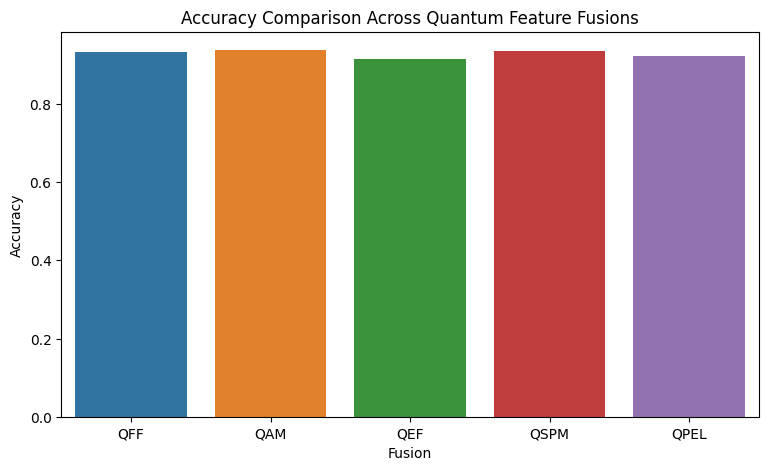


Best Performing Fusion: QAM (Accuracy=0.9375)
Best model saved as: Best_QuantumFusion_Model.h5


In [7]:
# ===========================================================
#  Xception with All 5 Quantum Feature Fusions + Save Best Model
# ===========================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np, gc, time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
import shutil

print(" TensorFlow version:", tf.__version__)

FUSION_TYPES = ["QFF", "QAM", "QEF", "QSPM", "QPEL"]
RESULTS = []

# ===========================================================
# Quantum Layer Definitions (Error-Free)
# ===========================================================

class QuantumFeatureFusion(layers.Layer):
    def __init__(self, dim):
        super().__init__()
        self.theta = layers.Dense(dim)
        self.amp = layers.Dense(dim)
    def build(self, input_shape):
        self.alpha = self.add_weight(
            name="alpha", shape=(1,),
            initializer=tf.keras.initializers.Constant(0.6),
            trainable=True, dtype=tf.float32)
    def call(self, x):
        phi = tf.sigmoid(self.theta(x)) * np.pi
        A = tf.sigmoid(self.amp(x))
        return x + self.alpha * (tf.cos(phi) * x * A + tf.sin(phi) * x * (1 - A))

class QuantumAttention(layers.Layer):
    def __init__(self, dim):
        super().__init__()
        self.phase = layers.Dense(dim)
        self.amp = layers.Dense(dim)
    def build(self, input_shape):
        self.gamma = self.add_weight(
            name="gamma", shape=(1,),
            initializer=tf.keras.initializers.Constant(0.7),
            trainable=True, dtype=tf.float32)
    def call(self, x):
        theta = tf.sigmoid(self.phase(x)) * np.pi
        A = tf.sigmoid(self.amp(x))
        att = tf.cos(theta) * A + tf.sin(theta) * (1 - A)
        return x * (1 + self.gamma * att)

class QuantumEntanglement(layers.Layer):
    def __init__(self, dim):
        super().__init__()
        self.W1, self.W2, self.W3 = layers.Dense(dim), layers.Dense(dim), layers.Dense(dim)
        self.out = layers.Dense(dim)
    def build(self, input_shape):
        self.beta = self.add_weight(
            name="beta", shape=(1,),
            initializer=tf.keras.initializers.Constant(0.5),
            trainable=True, dtype=tf.float32)
    def call(self, inputs):
        f1, f2, f3 = inputs
        e12 = tf.tanh(self.W1(f1) * self.W2(f2))
        e23 = tf.tanh(self.W2(f2) * self.W3(f3))
        e31 = tf.tanh(self.W3(f3) * self.W1(f1))
        ent = tf.concat([e12, e23, e31], axis=-1)
        fused = self.out(ent)
        return fused + self.beta * fused

class QuantumStateProjection(layers.Layer):
    def __init__(self, dim):
        super().__init__()
        self.U = layers.Dense(dim, use_bias=False, kernel_initializer="orthogonal")
    def build(self, input_shape):
        self.gamma = self.add_weight(
            name="gamma", shape=(1,),
            initializer=tf.keras.initializers.Constant(0.5),
            trainable=True, dtype=tf.float32)
    def call(self, x):
        Ux = tf.nn.l2_normalize(self.U(x), axis=-1)
        proj = tf.matmul(Ux, self.U.kernel, transpose_b=True)
        return x + self.gamma * proj

class QuantumPhaseEncoding(layers.Layer):
    def __init__(self, dim):
        super().__init__()
        self.phase = layers.Dense(dim)
    def build(self, input_shape):
        self.delta = self.add_weight(
            name="delta", shape=(1,),
            initializer=tf.keras.initializers.Constant(0.4),
            trainable=True, dtype=tf.float32)
    def call(self, x):
        phi = tf.sigmoid(self.phase(x)) * np.pi
        enc = tf.cos(phi) * x + tf.sin(phi) * x
        return x + self.delta * enc

# ===========================================================
# Build Fusion Model
# ===========================================================
def build_xception_fusion(fusion_type="QFF", img_size=224, proj_dim=512, num_classes=2):
    base = tf.keras.applications.Xception(weights="imagenet", include_top=False, input_shape=(img_size, img_size, 3))
    layer_names = ["block3_sepconv2_act", "block10_sepconv2_act", "block13_sepconv2_act"]
    feats = [base.get_layer(n).output for n in layer_names]
    feat_model = tf.keras.Model(base.input, feats)

    inp = layers.Input(shape=(img_size, img_size, 3))
    fmaps = feat_model(inp)
    pooled = [layers.GlobalAveragePooling2D()(f) for f in fmaps]
    proj = [layers.Dense(proj_dim, activation="relu")(p) for p in pooled]

    if fusion_type == "QFF":
        fused = [QuantumFeatureFusion(proj_dim)(p) for p in proj]; x = layers.Concatenate()(fused)
    elif fusion_type == "QAM":
        fused = [QuantumAttention(proj_dim)(p) for p in proj]; x = layers.Concatenate()(fused)
    elif fusion_type == "QEF":
        x = QuantumEntanglement(proj_dim)(proj)
    elif fusion_type == "QSPM":
        fused = [QuantumStateProjection(proj_dim)(p) for p in proj]; x = layers.Concatenate()(fused)
    elif fusion_type == "QPEL":
        fused = [QuantumPhaseEncoding(proj_dim)(p) for p in proj]; x = layers.Concatenate()(fused)
    else:
        x = layers.Concatenate()(proj)

    x = layers.Dense(512, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)
    return keras.Model(inp, out, name=f"Xception_{fusion_type}")

# ===========================================================
# Training Loop + Save Best Performing Model
# ===========================================================
best_model_name = None
best_acc = 0.0

for fusion in FUSION_TYPES:
    print(f"\n==============================")
    print(f" TRAINING FUSION: {fusion}")
    print(f"==============================")
    tf.keras.backend.clear_session(); gc.collect()

    model = build_xception_fusion(fusion)
    model.compile(optimizer=keras.optimizers.Adam(1e-4),
                  loss="categorical_crossentropy", metrics=["accuracy"])

    ckpt = f"best_{fusion}.h5"
    callbacks = [
        keras.callbacks.ModelCheckpoint(ckpt, monitor="val_accuracy", save_best_only=True, verbose=1),
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    ]

    start = time.time()
    history = model.fit(train_dataset, validation_data=val_dataset, epochs=30, callbacks=callbacks, verbose=1)
    train_time = time.time() - start

    # Evaluate
    model.load_weights(ckpt)
    y_true, y_pred = [], []
    for imgs, lbls in test_dataset:
        preds = model.predict(imgs, verbose=0)
        y_true.extend(np.argmax(lbls, axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n🔹 {fusion} Results:")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-score: {f1:.4f}")

    # Save best model overall
    if acc > best_acc:
        best_acc = acc
        best_model_name = fusion
        shutil.copy(ckpt, "Best_QuantumFusion_Model.h5")
        print(f" Saved new best model: {fusion} (Accuracy={acc:.4f})")

    RESULTS.append({"Fusion": fusion, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "TrainTime(s)": train_time})
    pd.DataFrame(RESULTS).to_csv("fusion_results.csv", index=False)

    del model; gc.collect()

# ===========================================================
# Final Comparison Summary
# ===========================================================
df = pd.DataFrame(RESULTS)
print("\n📊 FINAL SUMMARY (All Quantum Fusions):")
print(df)

plt.figure(figsize=(9, 5))
sns.barplot(x="Fusion", y="Accuracy", data=df)
plt.title("Accuracy Comparison Across Quantum Feature Fusions")
plt.show()

print(f"\nBest Performing Fusion: {best_model_name} (Accuracy={best_acc:.4f})")
print("Best model saved as: Best_QuantumFusion_Model.h5")

In [8]:
# ===========================================================
# 📄 Display Model Summaries for All Quantum Fusion Models
# ===========================================================

for fusion in ["QFF", "QAM", "QEF", "QSPM", "QPEL"]:
    print(f"\n==============================")
    print(f" MODEL SUMMARY: {fusion}")
    print(f"==============================")

    model = build_xception_fusion(fusion)
    model.summary()

    # Optional: save each summary to a .txt file
    with open(f"{fusion}_summary.txt", "w") as f:
        model.summary(print_fn=lambda x: f.write(x + "\n"))

print("\nAll model summaries displayed and saved as:")
print("   QFF_summary.txt, QAM_summary.txt, QEF_summary.txt, QSPM_summary.txt, QPEL_summary.txt")



 MODEL SUMMARY: QFF


Model: "Xception_QFF"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_1        │ [(None, 55, 55,   │ 14,599,824 │ input_layer_3[0]… │
│ (Functional)        │ 256), (None, 14,  │            │                   │
│                     │ 14, 728), (None,  │            │                   │
│                     │ 14, 14, 728)]     │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ functional_1[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 728)       │          0 │ functional_1[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 728)       │          0 │ functional_1[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 512)       │    131,584 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 512)       │    373,248 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 512)       │    373,248 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ quantum_feature_fu… │ (None, 512)       │    525,313 │ dense_9[0][0]     │
│ (QuantumFeatureFus… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ quantum_feature_fu… │ (None, 512)       │    525,313 │ dense_10[0][0]    │
│ (QuantumFeatureFus… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ quantum_feature_fu… │ (None, 512)       │    525,313 │ dense_11[0][0]    │
│ (QuantumFeatureFus… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 1536)      │          0 │ quantum_feature_… │
│ (Concatenate)       │                   │            │ quantum_feature_… │
│                     │                   │            │ quantum_feature_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 512)       │    786,944 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_18[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 128)       │     65,664 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 2)         │        258 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 17,908,757 (68.32 MB)

 Trainable params: 17,864,469 (68.15 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_5        │ [(None, 55, 55,   │ 14,599,824 │ input_layer_11[0… │
│ (Functional)        │ 256), (None, 14,  │            │                   │
│                     │ 14, 728), (None,  │            │                   │
│                     │ 14, 14, 728)]     │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ functional_5[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 728)       │          0 │ functional_5[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 728)       │          0 │ functional_5[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_52 (Dense)    │ (None, 512)       │    131,584 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_53 (Dense)    │ (None, 512)       │    373,248 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_54 (Dense)    │ (None, 512)       │    373,248 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ quantum_phase_enco… │ (None, 512)       │    262,657 │ dense_52[0][0]    │
│ (QuantumPhaseEncod… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ quantum_phase_enco… │ (None, 512)       │    262,657 │ dense_53[0][0]    │
│ (QuantumPhaseEncod… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ quantum_phase_enco… │ (None, 512)       │    262,657 │ dense_54[0][0]    │
│ (QuantumPhaseEncod… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 1536)      │          0 │ quantum_phase_en… │
│ (Concatenate)       │                   │            │ quantum_phase_en… │
│                     │                   │            │ quantum_phase_en… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_58 (Dense)    │ (None, 512)       │    786,944 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_58[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 512)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_59 (Dense)    │ (None, 128)       │     65,664 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 128)       │          0 │ dense_59[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 17,120,789 (65.31 MB)

 Trainable params: 17,076,501 (65.14 MB)

 Non-trainable params: 44,288 (173.00 KB)


All model summaries displayed and saved as:
   QFF_summary.txt, QAM_summary.txt, QEF_summary.txt, QSPM_summary.txt, QPEL_summary.txt



 PERFORMANCE SUMMARY ACROSS QUANTUM FEATURE FUSIONS

Fusion  Accuracy  Precision   Recall       F1  TrainTime(s)
   QFF  0.933125   0.915289 0.870334 0.892246    533.705457
   QAM  0.937500   0.918200 0.882122 0.899800    582.792651
   QEF  0.913750   0.936471 0.781925 0.852248    519.726940
  QSPM  0.935625   0.933761 0.858546 0.894575    753.995716
  QPEL  0.923125   0.982500 0.772102 0.864686    578.071197

 BEST FUSION:
Fusion Type : QAM
Accuracy    : 0.9375
Precision   : 0.9182
Recall      : 0.8821
F1-score    : 0.8998

 Saved detailed summary to 'Quantum_Fusion_Results_Summary.xlsx'


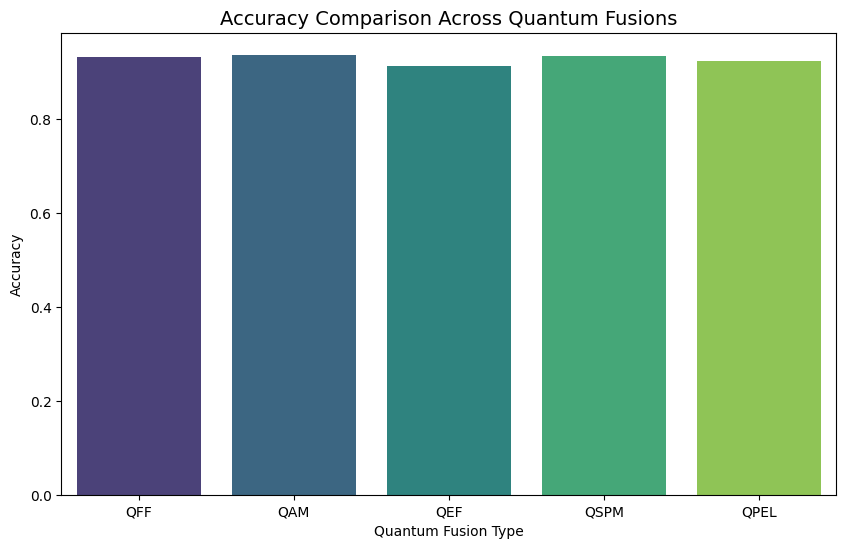

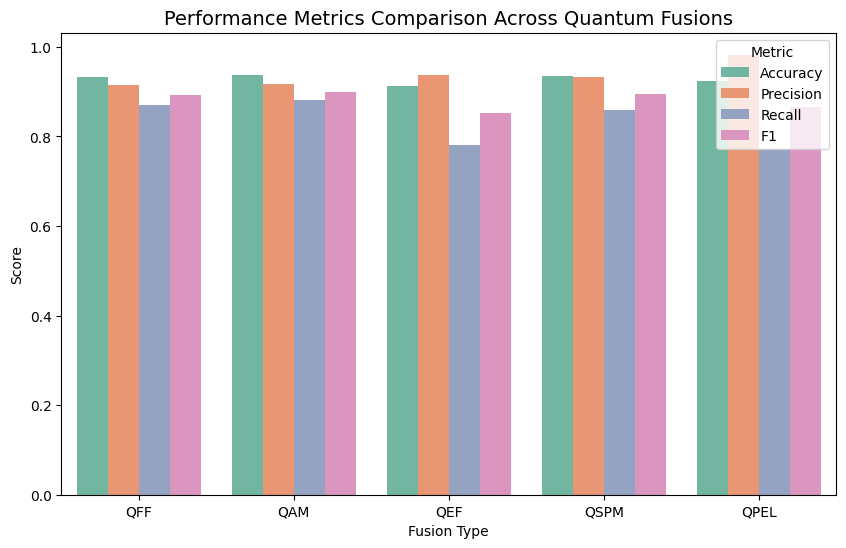

In [9]:
# ===========================================================
#  Summary Table: Accuracy, Precision, Recall, F1-score for All Fusions
# ===========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load saved results from fusion_results.csv
df = pd.read_csv("fusion_results.csv")

# Print nicely formatted summary
print("\n PERFORMANCE SUMMARY ACROSS QUANTUM FEATURE FUSIONS\n")
print(df.to_string(index=False))

# Identify the best-performing fusion
best_fusion = df.loc[df["Accuracy"].idxmax()]
print("\n BEST FUSION:")
print(f"Fusion Type : {best_fusion['Fusion']}")
print(f"Accuracy    : {best_fusion['Accuracy']:.4f}")
print(f"Precision   : {best_fusion['Precision']:.4f}")
print(f"Recall      : {best_fusion['Recall']:.4f}")
print(f"F1-score    : {best_fusion['F1']:.4f}")

# Save the table to Excel for report usage
df.to_excel("Quantum_Fusion_Results_Summary.xlsx", index=False)
print("\n Saved detailed summary to 'Quantum_Fusion_Results_Summary.xlsx'")

# ===========================================================
#  Visualization: Compare Metrics
# ===========================================================
plt.figure(figsize=(10,6))
sns.barplot(x="Fusion", y="Accuracy", data=df, palette="viridis")
plt.title("Accuracy Comparison Across Quantum Fusions", fontsize=14)
plt.ylabel("Accuracy")
plt.xlabel("Quantum Fusion Type")
plt.show()

# Multi-metric plot
metrics_df = df.melt(id_vars=["Fusion"], value_vars=["Accuracy","Precision","Recall","F1"],
                     var_name="Metric", value_name="Score")

plt.figure(figsize=(10,6))
sns.barplot(x="Fusion", y="Score", hue="Metric", data=metrics_df, palette="Set2")
plt.title("Performance Metrics Comparison Across Quantum Fusions", fontsize=14)
plt.ylabel("Score")
plt.xlabel("Fusion Type")
plt.legend(title="Metric")
plt.show()



 Evaluating Fusion: QFF
 Loaded weights from: best_QFF.h5


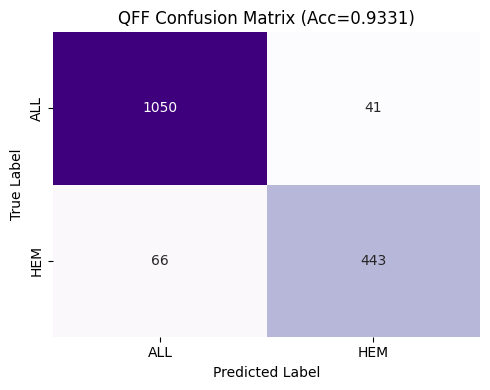


 Evaluating Fusion: QAM
 Loaded weights from: best_QAM.h5


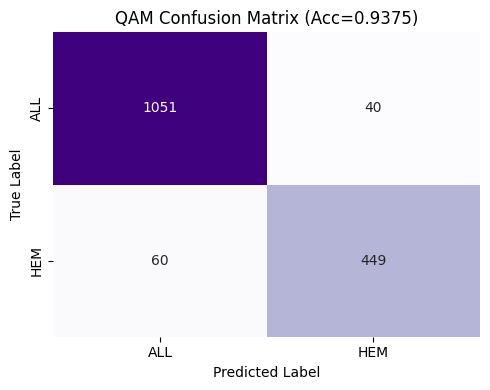


 Evaluating Fusion: QEF
 Loaded weights from: best_QEF.h5


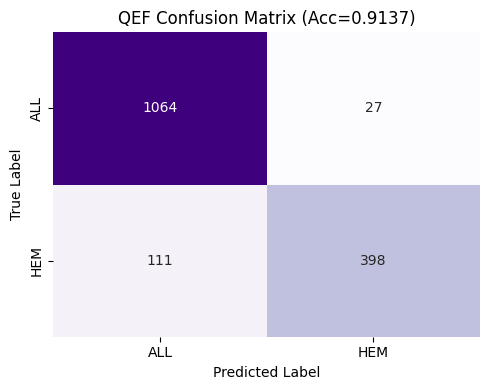


 Evaluating Fusion: QSPM
 Loaded weights from: best_QSPM.h5


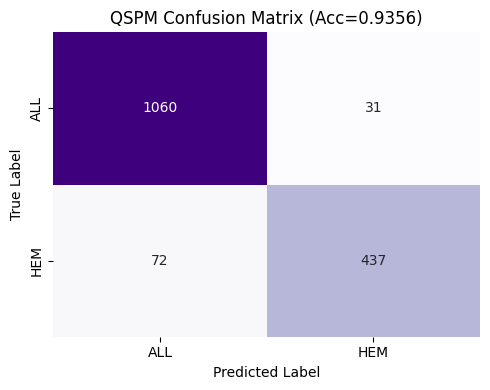


 Evaluating Fusion: QPEL
 Loaded weights from: best_QPEL.h5


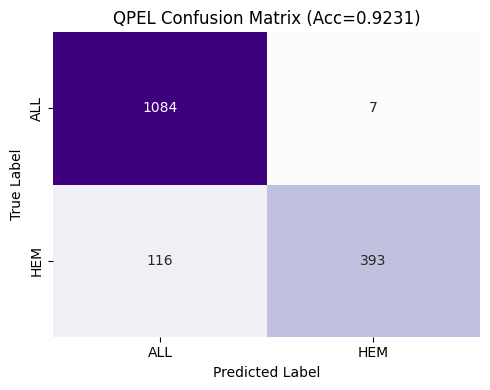


 All confusion matrices plotted and saved as:
   QFF_confusion_matrix.png, QAM_confusion_matrix.png, QEF_confusion_matrix.png, QSPM_confusion_matrix.png, QPEL_confusion_matrix.png


In [10]:
# ===========================================================
#  Confusion Matrix Visualization for All Quantum Fusions
# ===========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

FUSION_TYPES = ["QFF", "QAM", "QEF", "QSPM", "QPEL"]

# Function to evaluate and plot confusion matrix
def plot_confusion_matrix_for_fusion(fusion_type):
    print(f"\n==============================")
    print(f" Evaluating Fusion: {fusion_type}")
    print(f"==============================")

    # Rebuild model (must match architecture)
    model = build_xception_fusion(fusion_type)
    
    # Load the best weights from saved .h5 file
    weight_path = f"best_{fusion_type}.h5"
    try:
        model.load_weights(weight_path)
        print(f" Loaded weights from: {weight_path}")
    except:
        print(f" Warning: Weights file not found for {fusion_type}. Skipping...")
        return

    # Evaluate on test dataset
    y_true, y_pred = [], []
    for imgs, lbls in test_dataset:
        preds = model.predict(imgs, verbose=0)
        y_true.extend(np.argmax(lbls, axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
                xticklabels=["ALL", "HEM"],
                yticklabels=["ALL", "HEM"])
    plt.title(f"{fusion_type} Confusion Matrix (Acc={acc:.4f})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()

    # Save each confusion matrix figure
    plt.savefig(f"{fusion_type}_confusion_matrix.png", dpi=300)
    plt.show()

    del model
    gc.collect()

# ===========================================================
#  Loop through all 5 fusion types
# ===========================================================
for fusion in FUSION_TYPES:
    plot_confusion_matrix_for_fusion(fusion)

print("\n All confusion matrices plotted and saved as:")
print("   QFF_confusion_matrix.png, QAM_confusion_matrix.png, QEF_confusion_matrix.png, QSPM_confusion_matrix.png, QPEL_confusion_matrix.png")


In [11]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# ======================================================
# Include your FIXED custom layers (same as before)
# ======================================================

class QuantumFeatureFusion(keras.layers.Layer):
    def __init__(self, dim, **kwargs):
        super().__init__(**kwargs)
        self.theta = keras.layers.Dense(dim)
        self.amp = keras.layers.Dense(dim)
    def build(self, input_shape):
        self.alpha = self.add_weight(name="alpha", shape=(1,),
                                     initializer=tf.keras.initializers.Constant(0.6))
    def call(self, x):
        phi = tf.sigmoid(self.theta(x)) * np.pi
        A = tf.sigmoid(self.amp(x))
        return x + self.alpha * (tf.cos(phi)*x*A + tf.sin(phi)*x*(1-A))


class QuantumAttention(keras.layers.Layer):
    def __init__(self, dim, **kwargs):
        super().__init__(**kwargs)
        self.phase = keras.layers.Dense(dim)
        self.amp = keras.layers.Dense(dim)
    def build(self, input_shape):
        self.gamma = self.add_weight(name="gamma", shape=(1,),
                                     initializer=tf.keras.initializers.Constant(0.7))
    def call(self, x):
        theta = tf.sigmoid(self.phase(x)) * np.pi
        A = tf.sigmoid(self.amp(x))
        att = tf.cos(theta)*A + tf.sin(theta)*(1-A)
        return x * (1 + self.gamma * att)


class QuantumEntanglement(keras.layers.Layer):
    def __init__(self, dim, **kwargs):
        super().__init__(**kwargs)
        self.W1 = keras.layers.Dense(dim)
        self.W2 = keras.layers.Dense(dim)
        self.W3 = keras.layers.Dense(dim)
        self.out = keras.layers.Dense(dim)
    def build(self, input_shape):
        self.beta = self.add_weight(name="beta", shape=(1,),
                                     initializer=tf.keras.initializers.Constant(0.5))
    def call(self, inputs):
        f1, f2, f3 = inputs
        e12 = tf.tanh(self.W1(f1) * self.W2(f2))
        e23 = tf.tanh(self.W2(f2) * self.W3(f3))
        e31 = tf.tanh(self.W3(f3) * self.W1(f1))
        ent = tf.concat([e12, e23, e31], axis=-1)
        fused = self.out(ent)
        return fused + self.beta * fused


class QuantumStateProjection(keras.layers.Layer):
    def __init__(self, dim, **kwargs):
        super().__init__(**kwargs)
        self.U = keras.layers.Dense(dim, use_bias=False, kernel_initializer='orthogonal')
    def build(self, input_shape):
        self.gamma = self.add_weight(name="gamma", shape=(1,),
                                     initializer=tf.keras.initializers.Constant(0.5))
    def call(self, x):
        Ux = tf.nn.l2_normalize(self.U(x), axis=-1)
        proj = tf.matmul(Ux, self.U.kernel, transpose_b=True)
        return x + self.gamma * proj


class QuantumPhaseEncoding(keras.layers.Layer):
    def __init__(self, dim, **kwargs):
        super().__init__(**kwargs)
        self.phase = keras.layers.Dense(dim)
    def build(self, input_shape):
        self.delta = self.add_weight(name="delta", shape=(1,),
                                     initializer=tf.keras.initializers.Constant(0.4))
    def call(self, x):
        phi = tf.sigmoid(self.phase(x)) * np.pi
        enc = tf.cos(phi)*x + tf.sin(phi)*x
        return x + self.delta * enc


# ======================================================
# LOAD MODEL
# ======================================================

model = keras.models.load_model(
    "Best_QuantumFusion_Model.h5",
    custom_objects={
        "QuantumFeatureFusion": QuantumFeatureFusion,
        "QuantumAttention": QuantumAttention,
        "QuantumEntanglement": QuantumEntanglement,
        "QuantumStateProjection": QuantumStateProjection,
        "QuantumPhaseEncoding": QuantumPhaseEncoding
    }
)

print("Model Loaded Successfully for INT8 Conversion!")


# ======================================================
# INT8 QUANTIZATION (SMALLER THAN FP16)
# ======================================================

#  Representative dataset is REQUIRED for INT8
def representative_data():
    for images, _ in train_dataset.take(100):
        yield [tf.cast(images, tf.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.representative_dataset = representative_data

# Use INT8 operations
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

# Inputs/Outputs INT8
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

tflite_model_int8 = converter.convert()

# Save
with open("blood_QuantumFusion_Model_INT8.tflite", "wb") as f:
    f.write(tflite_model_int8)

print(" INT8 Quantized TFLite Model Saved!")
print(" File: blood_QuantumFusion_Model_INT8.tflite")


Model Loaded Successfully for INT8 Conversion!
INFO:tensorflow:Assets written to: /tmp/tmpn18z2bls/assets


INFO:tensorflow:Assets written to: /tmp/tmpn18z2bls/assets


Saved artifact at '/tmp/tmpn18z2bls'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  136009164422416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136009164409168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136012100378000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136009164413776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136009164421840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136012100383760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136012100379920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136012100384144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136012100371856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136012100379536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1360121003707

/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1763270114.420167      48 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1763270114.420211      48 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1763270114.563273      48 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8


 INT8 Quantized TFLite Model Saved!
 File: blood_QuantumFusion_Model_INT8.tflite


In [12]:
import os

file_path = "blood_QuantumFusion_Model_INT8.tflite"
size_in_kb = os.path.getsize(file_path) / 1024
size_in_mb = size_in_kb / 1024

print(f"Size: {size_in_kb:.2f} KB ({size_in_mb:.2f} MB)")


Size: 18657.91 KB (18.22 MB)
